In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, roc_auc_score,
                             f1_score, precision_score, recall_score)
import warnings
warnings.filterwarnings('ignore')
import time

print("All libraries loaded!")

# Load the data
df = pd.read_csv('creditcard.csv')

print(f"Dataset loaded: {len(df):,} transactions")
print(f"Columns: {len(df.columns)}")
print(f"\nClass distribution:")
print(f"  Normal (0):    {(df['Class']==0).sum():,} ({(df['Class']==0).mean():.3%})")
print(f"  Fraud (1):     {(df['Class']==1).sum():,} ({(df['Class']==1).mean():.3%})")
print(f"\nThis is EXTREMELY imbalanced: only 0.17% are frauds.")
print(f"Finding 492 needles in a haystack of 284,807 transactions.\n")
print(df.head())

All libraries loaded!
Dataset loaded: 284,807 transactions
Columns: 31

Class distribution:
  Normal (0):    284,315 (99.827%)
  Fraud (1):     492 (0.173%)

This is EXTREMELY imbalanced: only 0.17% are frauds.
Finding 492 needles in a haystack of 284,807 transactions.

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2 


PHASE 2: EXPLORATORY ANALYSIS


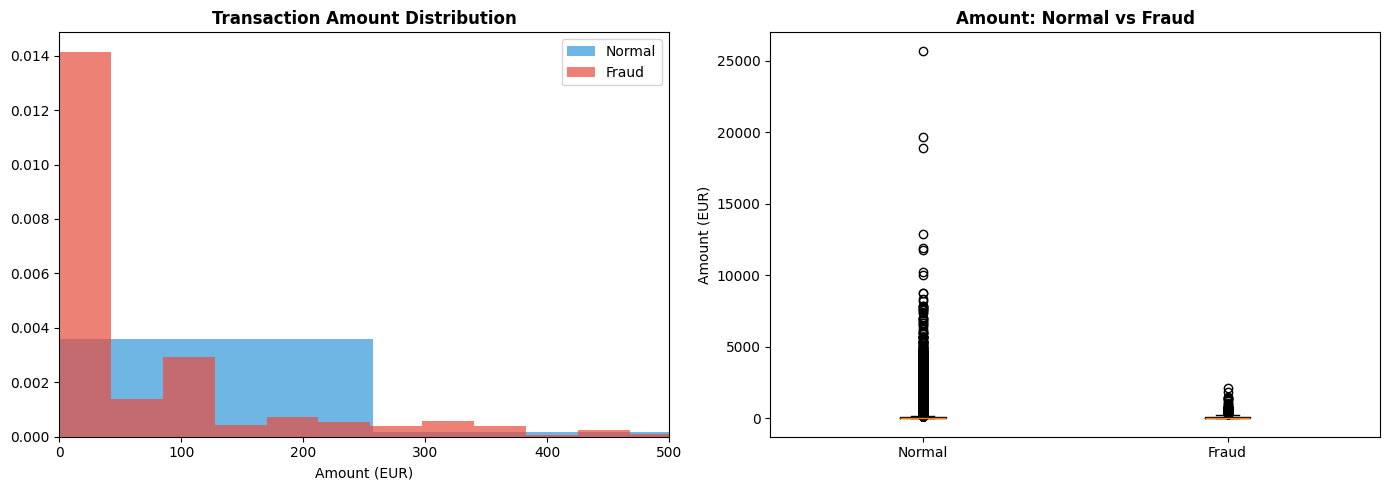

Amount statistics:
  Normal: mean=$88.29, median=$22.00
  Fraud:  mean=$122.21, median=$9.25


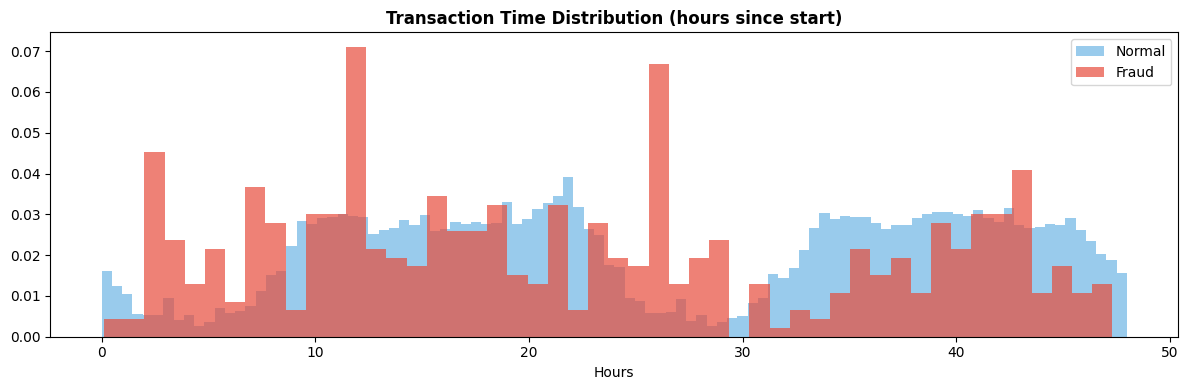

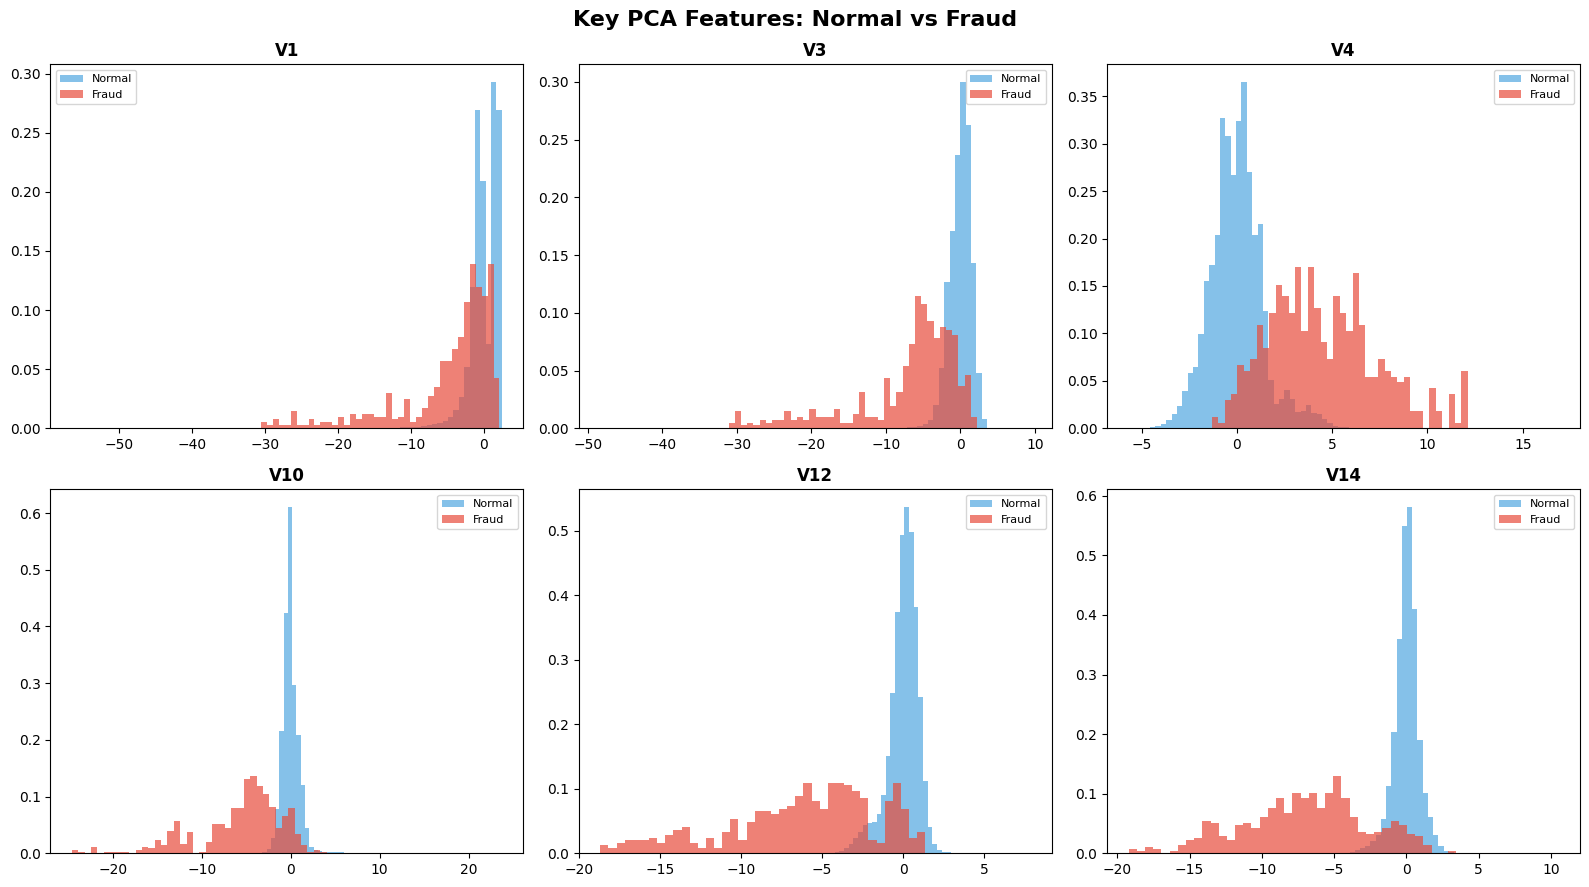

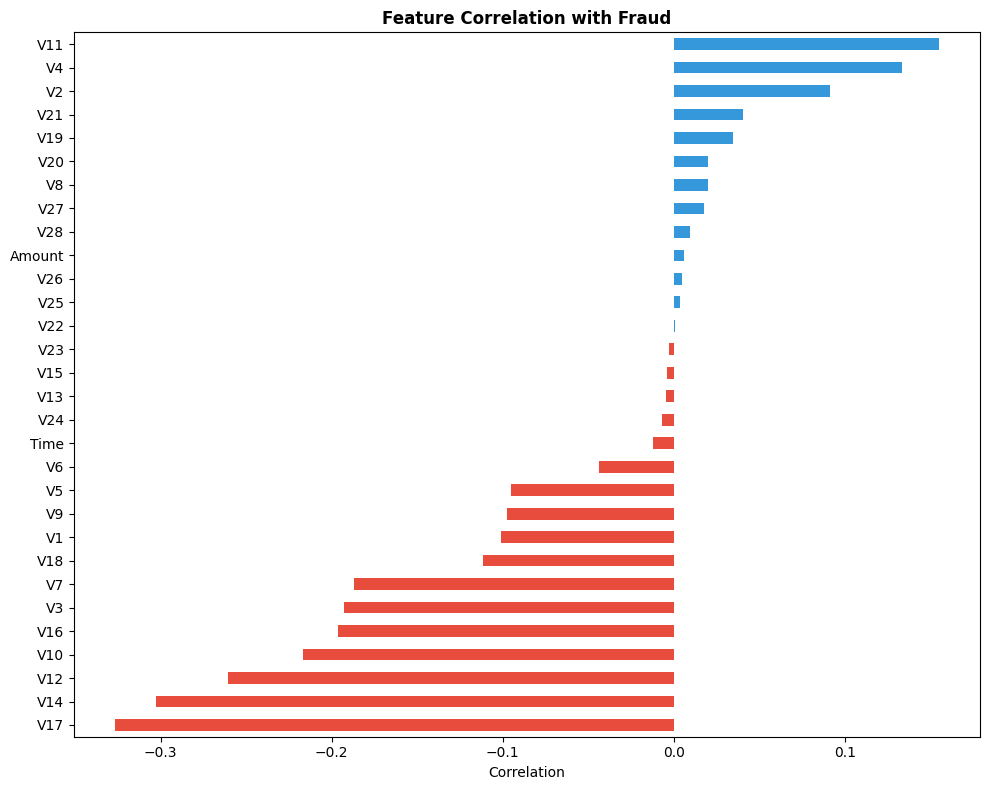

Top features NEGATIVELY correlated with fraud (fraud has lower values):
V17   -0.326
V14   -0.303
V12   -0.261
V10   -0.217
V16   -0.197
Name: Class, dtype: float64

Top features POSITIVELY correlated with fraud (fraud has higher values):
V19    0.035
V21    0.040
V2     0.091
V4     0.133
V11    0.155
Name: Class, dtype: float64


In [3]:
print("\n" + "=" * 70)
print("PHASE 2: EXPLORATORY ANALYSIS")
print("=" * 70)

# ---- STEP 2.1: Amount distribution ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Class']==0]['Amount'], bins=100, alpha=0.7,
             color='#3498db', label='Normal', density=True)
axes[0].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7,
             color='#e74c3c', label='Fraud', density=True)
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount (EUR)')
axes[0].legend()
axes[0].set_xlim(0, 500)  # Most transactions are under 500

axes[1].boxplot([df[df['Class']==0]['Amount'], df[df['Class']==1]['Amount']],
                labels=['Normal', 'Fraud'])
axes[1].set_title('Amount: Normal vs Fraud', fontweight='bold')
axes[1].set_ylabel('Amount (EUR)')

plt.tight_layout()
plt.savefig('01_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Amount statistics:")
print(f"  Normal: mean=${df[df['Class']==0]['Amount'].mean():.2f}, median=${df[df['Class']==0]['Amount'].median():.2f}")
print(f"  Fraud:  mean=${df[df['Class']==1]['Amount'].mean():.2f}, median=${df[df['Class']==1]['Amount'].median():.2f}")


# ---- STEP 2.2: Time distribution ----
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df[df['Class']==0]['Time']/3600, bins=100, alpha=0.5,
        color='#3498db', label='Normal', density=True)
ax.hist(df[df['Class']==1]['Time']/3600, bins=50, alpha=0.7,
        color='#e74c3c', label='Fraud', density=True)
ax.set_title('Transaction Time Distribution (hours since start)', fontweight='bold')
ax.set_xlabel('Hours')
ax.legend()
plt.tight_layout()
plt.savefig('02_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- STEP 2.3: Key PCA features ----
# Some V features separate fraud from normal better than others
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
important_features = ['V1', 'V3', 'V4', 'V10', 'V12', 'V14']

for i, feat in enumerate(important_features):
    ax = axes[i // 3][i % 3]
    normal = df[df['Class']==0][feat]
    fraud = df[df['Class']==1][feat]
    ax.hist(normal, bins=80, alpha=0.6, color='#3498db', label='Normal', density=True)
    ax.hist(fraud, bins=40, alpha=0.7, color='#e74c3c', label='Fraud', density=True)
    ax.set_title(f'{feat}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Key PCA Features: Normal vs Fraud', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('03_key_features.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- STEP 2.4: Correlation with fraud ----
correlations = df.corr()['Class'].drop('Class').sort_values()
fig, ax = plt.subplots(figsize=(10, 8))
correlations.plot(kind='barh', ax=ax, color=['#e74c3c' if x < 0 else '#3498db' for x in correlations])
ax.set_title('Feature Correlation with Fraud', fontweight='bold')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.savefig('04_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top features NEGATIVELY correlated with fraud (fraud has lower values):")
print(correlations.head(5).round(3))
print("\nTop features POSITIVELY correlated with fraud (fraud has higher values):")
print(correlations.tail(5).round(3))

In [4]:
print("\n" + "=" * 70)
print("PHASE 3: METHOD 1 — Z-SCORE")
print("=" * 70)

print("""
Z-SCORE: Flag transactions where ANY feature has |Z| > 3.
Limitation: checks each feature independently.
A fraud might look normal on every individual feature
but have an unusual COMBINATION of features.
""")

features = [f'V{i}' for i in range(1, 29)] + ['Amount']

# Scale Amount (V1-V28 are already PCA-scaled)
df['Amount_scaled'] = StandardScaler().fit_transform(df[['Amount']])

z_threshold = 3
z_features = features  # V1-V28 + Amount

# Calculate Z-scores
for feat in z_features:
    df[f'z_{feat}'] = np.abs((df[feat] - df[feat].mean()) / df[feat].std())

z_cols = [f'z_{feat}' for feat in z_features]
df['z_max'] = df[z_cols].max(axis=1)
df['z_anomaly'] = (df['z_max'] > z_threshold).astype(int)

# Results
z_detected = df['z_anomaly'].sum()
z_tp = ((df['z_anomaly']==1) & (df['Class']==1)).sum()
z_fp = ((df['z_anomaly']==1) & (df['Class']==0)).sum()
z_fn = ((df['z_anomaly']==0) & (df['Class']==1)).sum()
z_precision = z_tp / (z_tp + z_fp) if (z_tp + z_fp) > 0 else 0
z_recall = z_tp / (z_tp + z_fn) if (z_tp + z_fn) > 0 else 0
z_f1 = 2 * z_precision * z_recall / (z_precision + z_recall) if (z_precision + z_recall) > 0 else 0

print(f"Z-Score Results (threshold = {z_threshold}):")
print(f"  Flagged as anomaly:      {z_detected:,}")
print(f"  True Positives (fraud caught):  {z_tp}")
print(f"  False Positives (false alarms): {z_fp:,}")
print(f"  False Negatives (fraud missed): {z_fn}")
print(f"  Precision: {z_precision:.4f}")
print(f"  Recall:    {z_recall:.4f}")
print(f"  F1 Score:  {z_f1:.4f}")

# Drop temp columns to save memory
df.drop(columns=z_cols + ['z_max'], inplace=True)


PHASE 3: METHOD 1 — Z-SCORE

Z-SCORE: Flag transactions where ANY feature has |Z| > 3.
Limitation: checks each feature independently.
A fraud might look normal on every individual feature
but have an unusual COMBINATION of features.

Z-Score Results (threshold = 3):
  Flagged as anomaly:      37,816
  True Positives (fraud caught):  444
  False Positives (false alarms): 37,372
  False Negatives (fraud missed): 48
  Precision: 0.0117
  Recall:    0.9024
  F1 Score:  0.0232


In [5]:
print("\n" + "=" * 70)
print("PHASE 4: METHOD 2 — IQR")
print("=" * 70)

iqr_multiplier = 1.5
iqr_flags = pd.DataFrame()

for feat in z_features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - iqr_multiplier * IQR
    upper = Q3 + iqr_multiplier * IQR
    iqr_flags[feat] = ((df[feat] < lower) | (df[feat] > upper)).astype(int)

df['iqr_anomaly'] = (iqr_flags.max(axis=1) > 0).astype(int)

iqr_detected = df['iqr_anomaly'].sum()
iqr_tp = ((df['iqr_anomaly']==1) & (df['Class']==1)).sum()
iqr_fp = ((df['iqr_anomaly']==1) & (df['Class']==0)).sum()
iqr_fn = ((df['iqr_anomaly']==0) & (df['Class']==1)).sum()
iqr_precision = iqr_tp / (iqr_tp + iqr_fp) if (iqr_tp + iqr_fp) > 0 else 0
iqr_recall = iqr_tp / (iqr_tp + iqr_fn) if (iqr_tp + iqr_fn) > 0 else 0
iqr_f1 = 2 * iqr_precision * iqr_recall / (iqr_precision + iqr_recall) if (iqr_precision + iqr_recall) > 0 else 0

print(f"IQR Results (multiplier = {iqr_multiplier}):")
print(f"  Flagged as anomaly:      {iqr_detected:,}")
print(f"  True Positives:          {iqr_tp}")
print(f"  False Positives:         {iqr_fp:,}")
print(f"  False Negatives:         {iqr_fn}")
print(f"  Precision: {iqr_precision:.4f}")
print(f"  Recall:    {iqr_recall:.4f}")
print(f"  F1 Score:  {iqr_f1:.4f}")


PHASE 4: METHOD 2 — IQR
IQR Results (multiplier = 1.5):
  Flagged as anomaly:      138,473
  True Positives:          477
  False Positives:         137,996
  False Negatives:         15
  Precision: 0.0034
  Recall:    0.9695
  F1 Score:  0.0069



PHASE 5: METHOD 3 — ISOLATION FOREST

ISOLATION FOREST on real fraud data:
  - Uses ALL 29 features simultaneously (multivariate)
  - Detects unusual COMBINATIONS that Z-score/IQR miss
  - contamination=0.002 (we know ~0.17% are fraud)
  - This is the real test: can it find 492 frauds in 284,807 transactions?

Training Isolation Forest (this may take 1-2 minutes)...
Training complete in 12.8 seconds

Isolation Forest Results:
  Flagged as anomaly:      570
  True Positives:          161
  False Positives:         409
  False Negatives:         331
  Precision: 0.2825
  Recall:    0.3272
  F1 Score:  0.3032


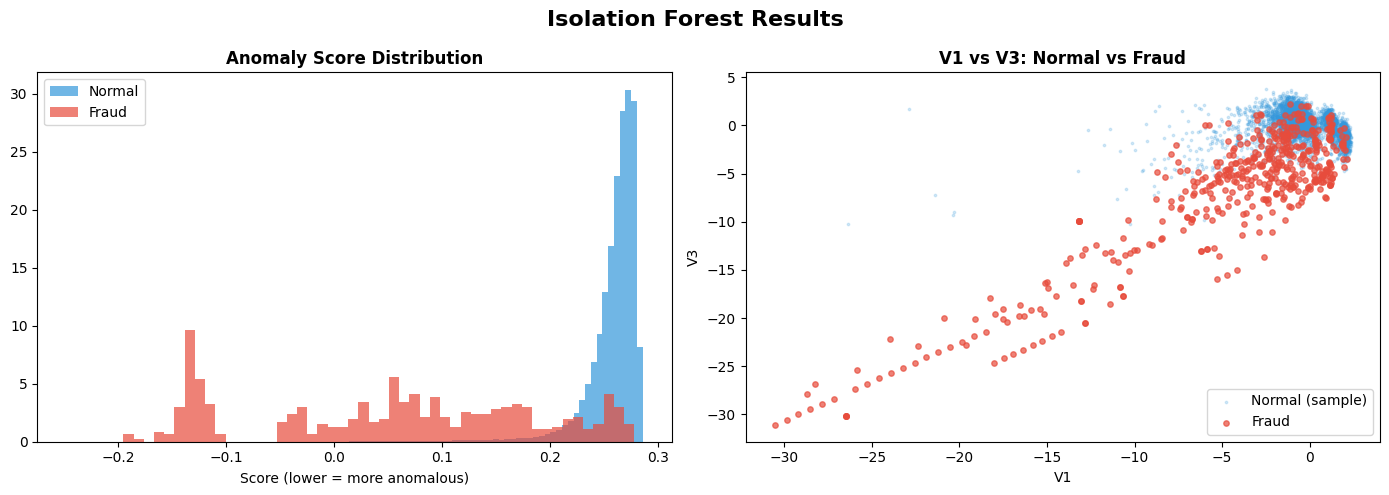

In [6]:
print("\n" + "=" * 70)
print("PHASE 5: METHOD 3 — ISOLATION FOREST")
print("=" * 70)

print("""
ISOLATION FOREST on real fraud data:
  - Uses ALL 29 features simultaneously (multivariate)
  - Detects unusual COMBINATIONS that Z-score/IQR miss
  - contamination=0.002 (we know ~0.17% are fraud)
  - This is the real test: can it find 492 frauds in 284,807 transactions?
""")

# Prepare features
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Isolation Forest
print("Training Isolation Forest (this may take 1-2 minutes)...")
start = time.time()

iso_forest = IsolationForest(
    contamination=0.002,  # expect ~0.2% anomalies
    n_estimators=200,
    max_samples=10000,    # subsample for speed on large dataset
    random_state=42,
    n_jobs=-1
)

iso_predictions = iso_forest.fit_predict(X_scaled)
elapsed = time.time() - start
print(f"Training complete in {elapsed:.1f} seconds")

df['iso_anomaly'] = (iso_predictions == -1).astype(int)
df['anomaly_score'] = iso_forest.decision_function(X_scaled)

iso_detected = df['iso_anomaly'].sum()
iso_tp = ((df['iso_anomaly']==1) & (df['Class']==1)).sum()
iso_fp = ((df['iso_anomaly']==1) & (df['Class']==0)).sum()
iso_fn = ((df['iso_anomaly']==0) & (df['Class']==1)).sum()
iso_precision = iso_tp / (iso_tp + iso_fp) if (iso_tp + iso_fp) > 0 else 0
iso_recall = iso_tp / (iso_tp + iso_fn) if (iso_tp + iso_fn) > 0 else 0
iso_f1 = 2 * iso_precision * iso_recall / (iso_precision + iso_recall) if (iso_precision + iso_recall) > 0 else 0

print(f"\nIsolation Forest Results:")
print(f"  Flagged as anomaly:      {iso_detected:,}")
print(f"  True Positives:          {iso_tp}")
print(f"  False Positives:         {iso_fp:,}")
print(f"  False Negatives:         {iso_fn}")
print(f"  Precision: {iso_precision:.4f}")
print(f"  Recall:    {iso_recall:.4f}")
print(f"  F1 Score:  {iso_f1:.4f}")


# ---- STEP 5.1: Anomaly score analysis ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
axes[0].hist(df[df['Class']==0]['anomaly_score'], bins=100, alpha=0.7,
             color='#3498db', label='Normal', density=True)
axes[0].hist(df[df['Class']==1]['anomaly_score'], bins=50, alpha=0.7,
             color='#e74c3c', label='Fraud', density=True)
axes[0].set_title('Anomaly Score Distribution', fontweight='bold')
axes[0].set_xlabel('Score (lower = more anomalous)')
axes[0].legend()

# V1 vs V3 scatter (two features that separate fraud well)
sample_normal = df[df['Class']==0].sample(5000, random_state=42)
sample_fraud = df[df['Class']==1]

axes[1].scatter(sample_normal['V1'], sample_normal['V3'],
                c='#3498db', s=3, alpha=0.2, label='Normal (sample)')
axes[1].scatter(sample_fraud['V1'], sample_fraud['V3'],
                c='#e74c3c', s=15, alpha=0.7, label='Fraud')
axes[1].set_title('V1 vs V3: Normal vs Fraud', fontweight='bold')
axes[1].set_xlabel('V1')
axes[1].set_ylabel('V3')
axes[1].legend()

plt.suptitle('Isolation Forest Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('05_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()



PHASE 6: METHOD COMPARISON
          Method  Detected  True Positives  False Positives  False Negatives  Precision  Recall  F1 Score
         Z-Score     37816             444            37372               48     0.0117  0.9024    0.0232
             IQR    138473             477           137996               15     0.0034  0.9695    0.0069
Isolation Forest       570             161              409              331     0.2825  0.3272    0.3032


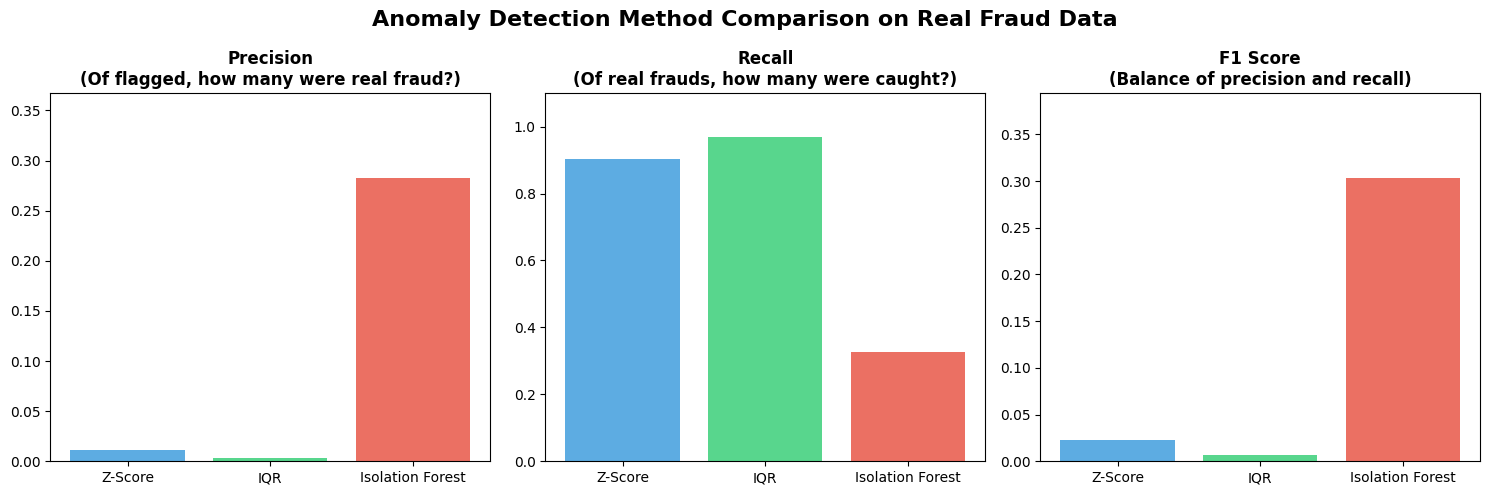

In [7]:
print("\n" + "=" * 70)
print("PHASE 6: METHOD COMPARISON")
print("=" * 70)

comparison = pd.DataFrame({
    'Method': ['Z-Score', 'IQR', 'Isolation Forest'],
    'Detected': [z_detected, iqr_detected, iso_detected],
    'True Positives': [z_tp, iqr_tp, iso_tp],
    'False Positives': [z_fp, iqr_fp, iso_fp],
    'False Negatives': [z_fn, iqr_fn, iso_fn],
    'Precision': [z_precision, iqr_precision, iso_precision],
    'Recall': [z_recall, iqr_recall, iso_recall],
    'F1 Score': [z_f1, iqr_f1, iso_f1]
}).round(4)

print(comparison.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
methods = ['Z-Score', 'IQR', 'Isolation Forest']
colors = ['#3498db', '#2ecc71', '#e74c3c']

axes[0].bar(methods, [z_precision, iqr_precision, iso_precision], color=colors, alpha=0.8)
axes[0].set_title('Precision\n(Of flagged, how many were real fraud?)', fontweight='bold')
axes[0].set_ylim(0, max(z_precision, iqr_precision, iso_precision) * 1.3)

axes[1].bar(methods, [z_recall, iqr_recall, iso_recall], color=colors, alpha=0.8)
axes[1].set_title('Recall\n(Of real frauds, how many were caught?)', fontweight='bold')
axes[1].set_ylim(0, 1.1)

axes[2].bar(methods, [z_f1, iqr_f1, iso_f1], color=colors, alpha=0.8)
axes[2].set_title('F1 Score\n(Balance of precision and recall)', fontweight='bold')
axes[2].set_ylim(0, max(z_f1, iqr_f1, iso_f1) * 1.3)

plt.suptitle('Anomaly Detection Method Comparison on Real Fraud Data',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('06_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


PHASE 7: PRECISION-RECALL ANALYSIS

IN FRAUD DETECTION, RECALL MATTERS MORE THAN PRECISION.
  Precision: "Of alerts, how many are real fraud?" (false alarm rate)
  Recall: "Of all frauds, how many did we catch?" (miss rate)

  Missing a $10,000 fraud (low recall) costs $10,000.
  Investigating a false alarm (low precision) costs $50 of analyst time.

  Therefore: optimize for HIGH RECALL, tolerate some false alarms.

Isolation Forest ROC AUC: 0.9545


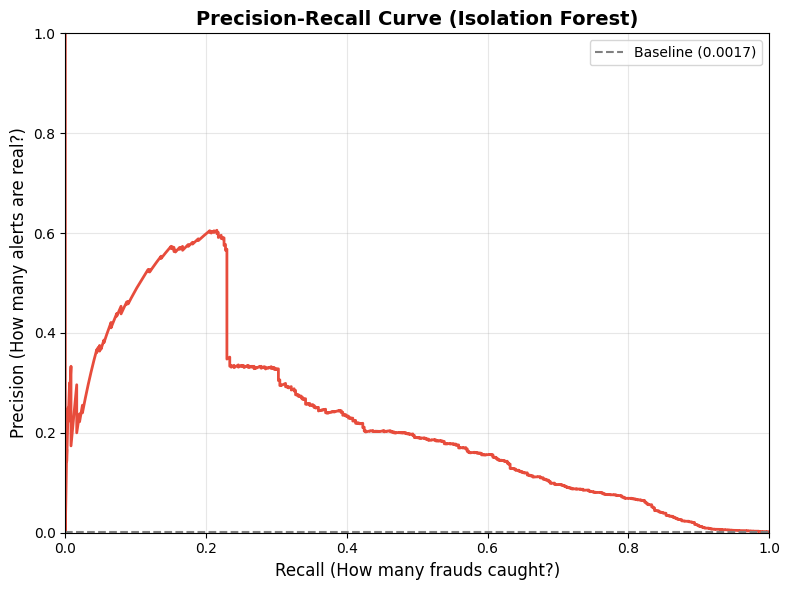

In [8]:
print("\n" + "=" * 70)
print("PHASE 7: PRECISION-RECALL ANALYSIS")
print("=" * 70)

print("""
IN FRAUD DETECTION, RECALL MATTERS MORE THAN PRECISION.
  Precision: "Of alerts, how many are real fraud?" (false alarm rate)
  Recall: "Of all frauds, how many did we catch?" (miss rate)

  Missing a $10,000 fraud (low recall) costs $10,000.
  Investigating a false alarm (low precision) costs $50 of analyst time.
  
  Therefore: optimize for HIGH RECALL, tolerate some false alarms.
""")

# Use anomaly_score from Isolation Forest for PR curve
precision_vals, recall_vals, thresholds = precision_recall_curve(
    df['Class'], -df['anomaly_score']  # negate because lower score = more anomalous
)

# ROC AUC
roc_auc = roc_auc_score(df['Class'], -df['anomaly_score'])
print(f"Isolation Forest ROC AUC: {roc_auc:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_vals, precision_vals, color='#e74c3c', linewidth=2)
ax.set_title('Precision-Recall Curve (Isolation Forest)', fontweight='bold', fontsize=14)
ax.set_xlabel('Recall (How many frauds caught?)', fontsize=12)
ax.set_ylabel('Precision (How many alerts are real?)', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.axhline(y=df['Class'].mean(), color='gray', linestyle='--', label=f'Baseline ({df["Class"].mean():.4f})')
ax.legend()
plt.tight_layout()
plt.savefig('07_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()



PHASE 8: FRAUD PATTERN ANALYSIS
Detected fraud: 161 transactions
Missed fraud:   331 transactions

Amount comparison:
  Detected fraud avg amount:   $97.80
  Missed fraud avg amount:     $134.08
  Normal avg amount:           $88.29

Feature means: Fraud vs Normal
Feature  Normal_Mean  Fraud_Mean  Abs_Diff
 Amount       88.291     122.211    33.920
     V3        0.012      -7.033     7.045
    V14        0.012      -6.972     6.984
    V17        0.012      -6.666     6.677
    V12        0.011      -6.259     6.270
    V10        0.010      -5.677     5.687
     V7        0.010      -5.569     5.578
     V1        0.008      -4.772     4.780
     V4       -0.008       4.542     4.550
    V16        0.007      -4.140     4.147


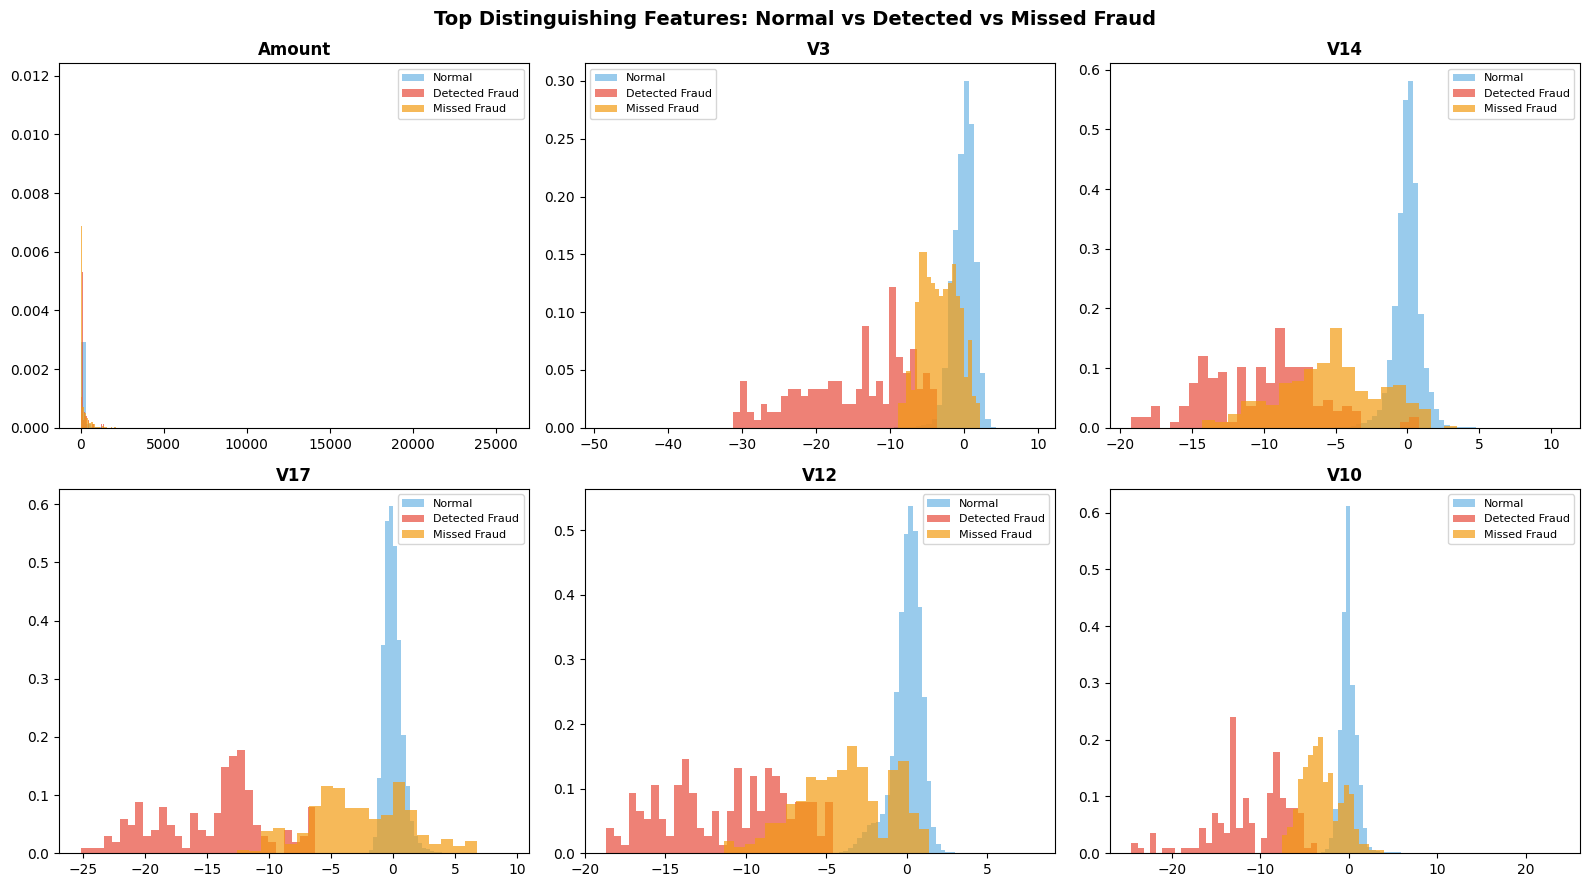

In [9]:
print("\n" + "=" * 70)
print("PHASE 8: FRAUD PATTERN ANALYSIS")
print("=" * 70)

# Analyze characteristics of detected fraud vs missed fraud
detected_fraud = df[(df['iso_anomaly']==1) & (df['Class']==1)]
missed_fraud = df[(df['iso_anomaly']==0) & (df['Class']==1)]

print(f"Detected fraud: {len(detected_fraud)} transactions")
print(f"Missed fraud:   {len(missed_fraud)} transactions")

print(f"\nAmount comparison:")
print(f"  Detected fraud avg amount:   ${detected_fraud['Amount'].mean():.2f}")
print(f"  Missed fraud avg amount:     ${missed_fraud['Amount'].mean():.2f}")
print(f"  Normal avg amount:           ${df[df['Class']==0]['Amount'].mean():.2f}")

# Which features most distinguish fraud
print(f"\nFeature means: Fraud vs Normal")
feature_diff = pd.DataFrame({
    'Feature': features,
    'Normal_Mean': [df[df['Class']==0][f].mean() for f in features],
    'Fraud_Mean': [df[df['Class']==1][f].mean() for f in features],
})
feature_diff['Abs_Diff'] = abs(feature_diff['Fraud_Mean'] - feature_diff['Normal_Mean'])
feature_diff = feature_diff.sort_values('Abs_Diff', ascending=False)
print(feature_diff.head(10).round(3).to_string(index=False))

# Top distinguishing features
top_features = feature_diff.head(6)['Feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, feat in enumerate(top_features):
    ax = axes[i//3][i%3]
    ax.hist(df[df['Class']==0][feat], bins=80, alpha=0.5, color='#3498db',
            label='Normal', density=True)
    ax.hist(detected_fraud[feat], bins=30, alpha=0.7, color='#e74c3c',
            label='Detected Fraud', density=True)
    if len(missed_fraud) > 0:
        ax.hist(missed_fraud[feat], bins=20, alpha=0.7, color='#f39c12',
                label='Missed Fraud', density=True)
    ax.set_title(f'{feat}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Top Distinguishing Features: Normal vs Detected vs Missed Fraud',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_fraud_patterns.png', dpi=150, bbox_inches='tight')
plt.show()



PHASE 9: CONFUSION MATRICES


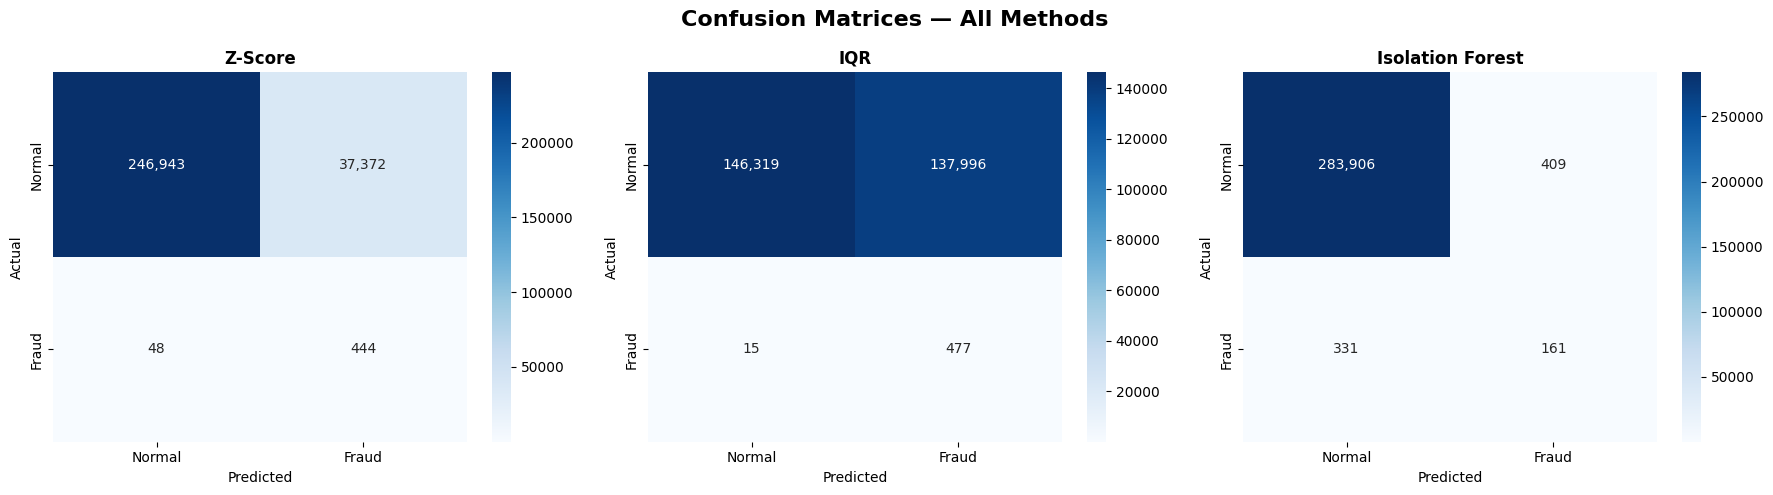

In [10]:
print("\n" + "=" * 70)
print("PHASE 9: CONFUSION MATRICES")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (method_name, pred_col) in enumerate([
    ('Z-Score', 'z_anomaly'), ('IQR', 'iqr_anomaly'), ('Isolation Forest', 'iso_anomaly')
]):
    cm = confusion_matrix(df['Class'], df[pred_col])
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    axes[i].set_title(f'{method_name}', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Methods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('09_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("\n" + "=" * 70)
print("     PROJECT 19 COMPLETE — ANOMALY DETECTION ON REAL FRAUD DATA")
print("=" * 70)
print(f"""
REAL DATASET:
  Kaggle Credit Card Fraud Detection
  284,807 transactions, 492 frauds (0.17%)
  Features: V1-V28 (PCA), Time, Amount

THREE METHODS COMPARED:
  Z-Score:         Precision={z_precision:.4f}, Recall={z_recall:.4f}, F1={z_f1:.4f}
  IQR:             Precision={iqr_precision:.4f}, Recall={iqr_recall:.4f}, F1={iqr_f1:.4f}
  Isolation Forest: Precision={iso_precision:.4f}, Recall={iso_recall:.4f}, F1={iso_f1:.4f}
  ROC AUC (Iso Forest): {roc_auc:.4f}

CHARTS GENERATED:
  01 -- Amount distribution (Normal vs Fraud)
  02 -- Time distribution
  03 -- Key PCA feature distributions
  04 -- Feature correlations with fraud
  05 -- Isolation Forest scatter + score distribution
  06 -- Method comparison (Precision, Recall, F1)
  07 -- Precision-Recall curve
  08 -- Fraud pattern analysis (detected vs missed)
  09 -- Confusion matrices for all 3 methods

KEY INSIGHTS:
  * Fraud transactions tend to be lower amount (harder to detect)
  * Certain PCA features (V14, V12, V10) strongly indicate fraud
  * Isolation Forest detects multivariate fraud patterns that
    Z-score/IQR miss when checking features independently
  * In fraud detection, RECALL > PRECISION (missing fraud costs more
    than investigating a false alarm)

KEY INTERVIEW ANSWERS:
  * "I applied anomaly detection on the Kaggle Credit Card Fraud dataset
     -- 284,807 real transactions with only 492 frauds (0.17%).
     Isolation Forest outperformed statistical methods because it detects
     multivariate patterns across 29 features simultaneously."
  
  * "In fraud detection, I optimize for RECALL over PRECISION because
     missing a $10,000 fraud costs $10,000, while investigating a
     false alarm costs $50 of analyst time."
  
  * "From my process safety background at HPCL, I apply the same
     anomaly detection thinking: monitor multiple sensors simultaneously,
     detect unusual combinations, categorize by severity, and trigger
     appropriate response actions."
""")
print("=" * 70)


     PROJECT 19 COMPLETE — ANOMALY DETECTION ON REAL FRAUD DATA

REAL DATASET:
  Kaggle Credit Card Fraud Detection
  284,807 transactions, 492 frauds (0.17%)
  Features: V1-V28 (PCA), Time, Amount

THREE METHODS COMPARED:
  Z-Score:         Precision=0.0117, Recall=0.9024, F1=0.0232
  IQR:             Precision=0.0034, Recall=0.9695, F1=0.0069
  Isolation Forest: Precision=0.2825, Recall=0.3272, F1=0.3032
  ROC AUC (Iso Forest): 0.9545

CHARTS GENERATED:
  01 -- Amount distribution (Normal vs Fraud)
  02 -- Time distribution
  03 -- Key PCA feature distributions
  04 -- Feature correlations with fraud
  05 -- Isolation Forest scatter + score distribution
  06 -- Method comparison (Precision, Recall, F1)
  07 -- Precision-Recall curve
  08 -- Fraud pattern analysis (detected vs missed)
  09 -- Confusion matrices for all 3 methods

KEY INSIGHTS:
  * Fraud transactions tend to be lower amount (harder to detect)
  * Certain PCA features (V14, V12, V10) strongly indicate fraud
  * Isolati